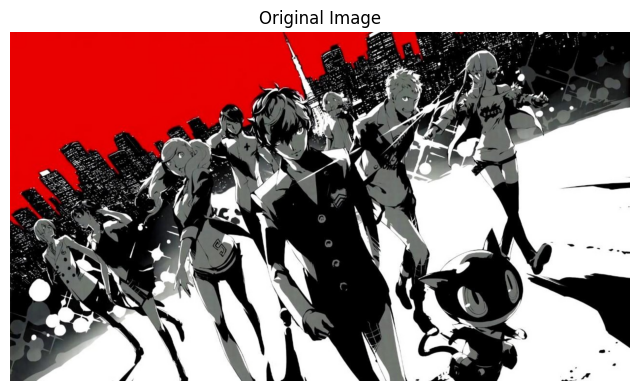

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Your local image path
image_path = r"D:\Anaconda\persona.jpg"

try:
    # Load the image from the local path and convert to an RGB numpy array
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)

    # Display the original image
    plt.figure(figsize=(8, 6))
    plt.imshow(img_array)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()
    
except FileNotFoundError:
    print(f"Error: Could not find the image at {image_path}.")
    print("Please double-check the folder path and file name.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [6]:

def kmeans_from_scratch(X, k, max_iters=100, tol=1e-4):
   
    # 1. Randomly initialize centroids by picking 'k' random pixels from the dataset
    np.random.seed(42)
    random_indices = np.random.choice(X.shape[0], k, replace=False)
    centroids = X[random_indices].astype(float)
    
    # Create an array to hold the distances and labels
    distances = np.zeros((X.shape[0], k))
    
    for iteration in range(max_iters):
        # 2. Calculate Euclidean distance from each pixel to each centroid
        for i in range(k):
            # Using linalg.norm computes the distance across the color channels (axis=1)
            distances[:, i] = np.linalg.norm(X - centroids[i], axis=1)
            
        # 3. Assign each pixel to the closest centroid
        labels = np.argmin(distances, axis=1)
        
        # 4. Update centroids by calculating the mean of the assigned pixels
        new_centroids = np.zeros_like(centroids)
        for i in range(k):
            # Extract all pixels assigned to cluster 'i'
            assigned_pixels = X[labels == i]
            
            if len(assigned_pixels) > 0:
                new_centroids[i] = np.mean(assigned_pixels, axis=0)
            else:
                # If a cluster is empty, re-initialize it randomly to avoid NaN errors
                new_centroids[i] = X[np.random.choice(X.shape[0])]
                
        # 5. Check for convergence (if centroids stop moving, we are done)
        centroid_shift = np.linalg.norm(centroids - new_centroids)
        if centroid_shift < tol:
            print(f"Converged at iteration {iteration}")
            break
            
        centroids = new_centroids
        
    return centroids, labels

Running K-Means with K=3...
Converged at iteration 9


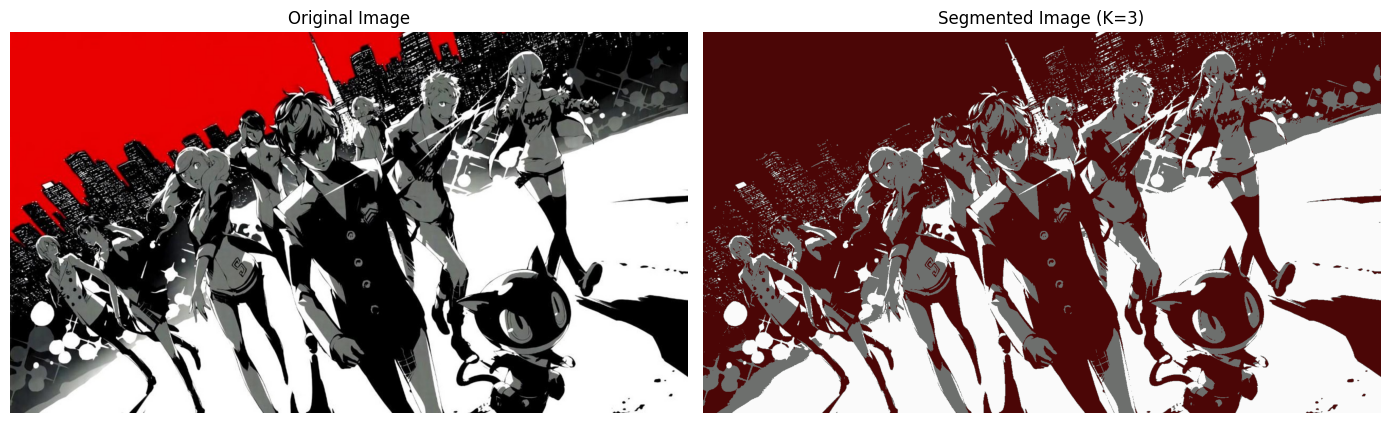

In [13]:
# Cell 3
# 1. Flatten the image: change shape from (H, W, 3) to (H*W, 3)
h, w, c = img_array.shape
X = img_array.reshape(-1, c)

# 2. Run our custom K-Means! Let's segment it into 5 colors.
# Note: K-means on high-res images can take a few seconds in pure python/numpy.
K = 3
print(f"Running K-Means with K={K}...")
centroids, labels = kmeans_from_scratch(X, k=K, max_iters=50)

# 3. Reconstruct the image
# Replace every pixel's color with the color of its assigned centroid
segmented_X = centroids[labels]

# Reshape back to the original image dimensions
segmented_img_array = segmented_X.reshape(h, w, c).astype(np.uint8)

# 4. Display the result side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(img_array)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(segmented_img_array)
ax[1].set_title(f"Segmented Image (K={K})")
ax[1].axis('off')

plt.tight_layout()
plt.show()